In [1]:
# CELL 1: Imports
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, LSTM

import warnings
warnings.filterwarnings('ignore')

In [2]:
# CELL 2: Load Data
print("=" * 60)
print("LOADING DATA FOR MODEL COMPARISON")
print("=" * 60)

# Static data
X_static_train = joblib.load("../models/X_static_train.pkl")
X_static_test = joblib.load("../models/X_static_test.pkl")

# LSTM data
X_lstm_train = joblib.load("../models/X_lstm_train.pkl")
X_lstm_test = joblib.load("../models/X_lstm_test.pkl")

# Target
y_train = joblib.load("../models/y_train.pkl")
y_test = joblib.load("../models/y_test.pkl")

# Threshold
threshold = joblib.load("../models/optimal_threshold.pkl")

print("✅ All data loaded successfully!")
print(f"\n📊 Static Train: {X_static_train.shape}")
print(f"📊 LSTM Train:   {X_lstm_train.shape}")
print(f"📊 Static Test:  {X_static_test.shape}")
print(f"📊 LSTM Test:    {X_lstm_test.shape}")

LOADING DATA FOR MODEL COMPARISON
✅ All data loaded successfully!

📊 Static Train: (12740, 16)
📊 LSTM Train:   (12740, 6, 1)
📊 Static Test:  (2000, 16)
📊 LSTM Test:    (2000, 6, 1)


In [3]:
# CELL 3: Build Standalone ANN Model
print("\n" + "=" * 60)
print("BUILDING STANDALONE ANN MODEL")
print("=" * 60)

def build_ann_model(input_shape):
    model = Sequential([
        Dense(128, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

ann_model = build_ann_model((X_static_train.shape[1],))
ann_model.compile(optimizer='adam', loss='binary_crossentropy', 
                  metrics=['accuracy'])
ann_model.summary()

print("\n✅ ANN model built")


BUILDING STANDALONE ANN MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 384 (1.50 KB)


✅ ANN model built


In [4]:
# CELL 4: Build Standalone LSTM Model (FIXED VERSION)
print("\n" + "=" * 60)
print("BUILDING STANDALONE LSTM MODEL")
print("=" * 60)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

def build_lstm_model(input_shape):
    """
    LSTM model with class weights to handle imbalance
    """
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    # Add class weights to handle imbalance
    class_weight = {0: 1.0, 1: 3.0}  # Weight churn class higher
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', AUC(name='auc')]
    )
    return model, class_weight

# Build the model
lstm_model, lstm_class_weight = build_lstm_model((X_lstm_train.shape[1], X_lstm_train.shape[2]))
lstm_model.compile(optimizer='adam', loss='binary_crossentropy',
                   metrics=['accuracy'])
lstm_model.summary()

print("\n✅ LSTM model built with class weights")



BUILDING STANDALONE LSTM MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 6, 64)               │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


✅ LSTM model built with class weights


In [5]:
# CELL 5: Load Pre-trained Fusion Model
print("\n" + "=" * 60)
print("LOADING PRE-TRAINED FUSION MODEL")
print("=" * 60)

fusion_model = tf.keras.models.load_model("../models/multimodal_churn_model.keras")
print("✅ Fusion model loaded successfully")


LOADING PRE-TRAINED FUSION MODEL
✅ Fusion model loaded successfully


In [6]:
# CELL 6: Train All Models (UPDATED)
print("\n" + "=" * 60)
print("TRAINING ALL MODELS")
print("=" * 60)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# Train ANN
print("\n🟢 Training ANN Model...")
ann_history = ann_model.fit(
    X_static_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
print("✅ ANN training complete")

# Train LSTM (WITH CLASS WEIGHTS)
print("\n🔵 Training LSTM Model...")
lstm_history = lstm_model.fit(
    X_lstm_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=lstm_class_weight,  # ADD THIS
    callbacks=[early_stop],
    verbose=0
)
print("✅ LSTM training complete")


TRAINING ALL MODELS

🟢 Training ANN Model...
✅ ANN training complete

🔵 Training LSTM Model...
✅ LSTM training complete


In [7]:
# CELL 7: Evaluate All Models
print("\n" + "=" * 60)
print("EVALUATING ALL MODELS")
print("=" * 60)

models = {
    'ANN': (ann_model, X_static_test),
    'LSTM': (lstm_model, X_lstm_test),
    'Fusion': (fusion_model, [X_static_test, X_lstm_test])
}

results = {}

for name, (model, X_test_data) in models.items():
    print(f"\n📊 Evaluating {name} Model...")
    
    # Get predictions
    y_pred_prob = model.predict(X_test_data).flatten()
    y_pred = (y_pred_prob > threshold).astype(int)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC': auc
    }
    
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   AUC:       {auc:.4f}")



EVALUATING ALL MODELS

📊 Evaluating ANN Model...
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
   Accuracy:  0.8165
   Precision: 0.5429
   Recall:    0.6216
   F1-Score:  0.5796
   AUC:       0.8371

📊 Evaluating LSTM Model...
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
   Accuracy:  0.4595
   Precision: 0.2355
   Recall:    0.7371
   F1-Score:  0.3569
   AUC:       0.5595

📊 Evaluating Fusion Model...
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
   Accuracy:  0.8455
   Precision: 0.6237
   Recall:    0.6069
   F1-Score:  0.6152
   AUC:       0.8540


In [8]:
# CELL 8: Display Comparison Table
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

results_df = pd.DataFrame(results).T
print("\n📊 Comparison Table:")
print(results_df.round(4))

# Find best model for each metric
best_accuracy = results_df['Accuracy'].idxmax()
best_f1 = results_df['F1-Score'].idxmax()
best_auc = results_df['AUC'].idxmax()

print(f"\n🏆 Best Accuracy: {best_accuracy}")
print(f"🏆 Best F1-Score: {best_f1}")
print(f"🏆 Best AUC: {best_auc}")


MODEL COMPARISON SUMMARY

📊 Comparison Table:
        Accuracy  Precision  Recall  F1-Score     AUC
ANN       0.8165     0.5429  0.6216    0.5796  0.8371
LSTM      0.4595     0.2355  0.7371    0.3569  0.5595
Fusion    0.8455     0.6237  0.6069    0.6152  0.8540

🏆 Best Accuracy: Fusion
🏆 Best F1-Score: Fusion
🏆 Best AUC: Fusion



VISUALIZING MODEL COMPARISON


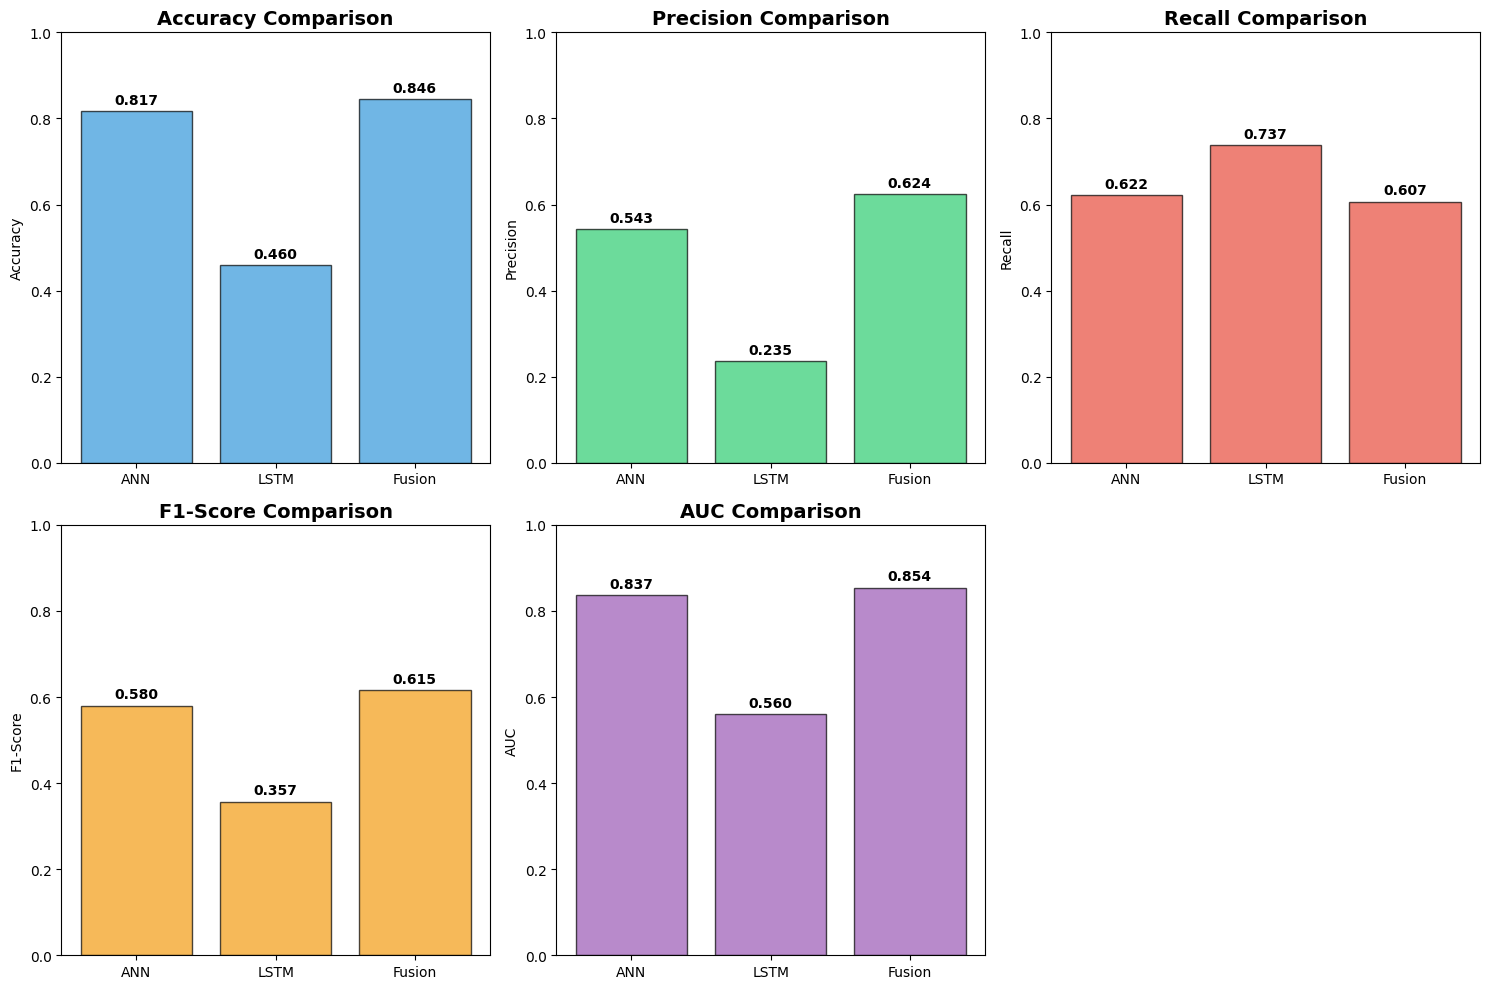

In [9]:
# CELL 9: Visualize Comparison
print("\n" + "=" * 60)
print("VISUALIZING MODEL COMPARISON")
print("=" * 60)

# Bar chart comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics):
    ax = axes[i]
    values = [results[model][metric] for model in results.keys()]
    bars = ax.bar(results.keys(), values, color=colors[i], alpha=0.7, edgecolor='black')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim([0, 1])
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Hide the 6th subplot (only 5 metrics)
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


CREATING SUMMARY VISUALIZATION


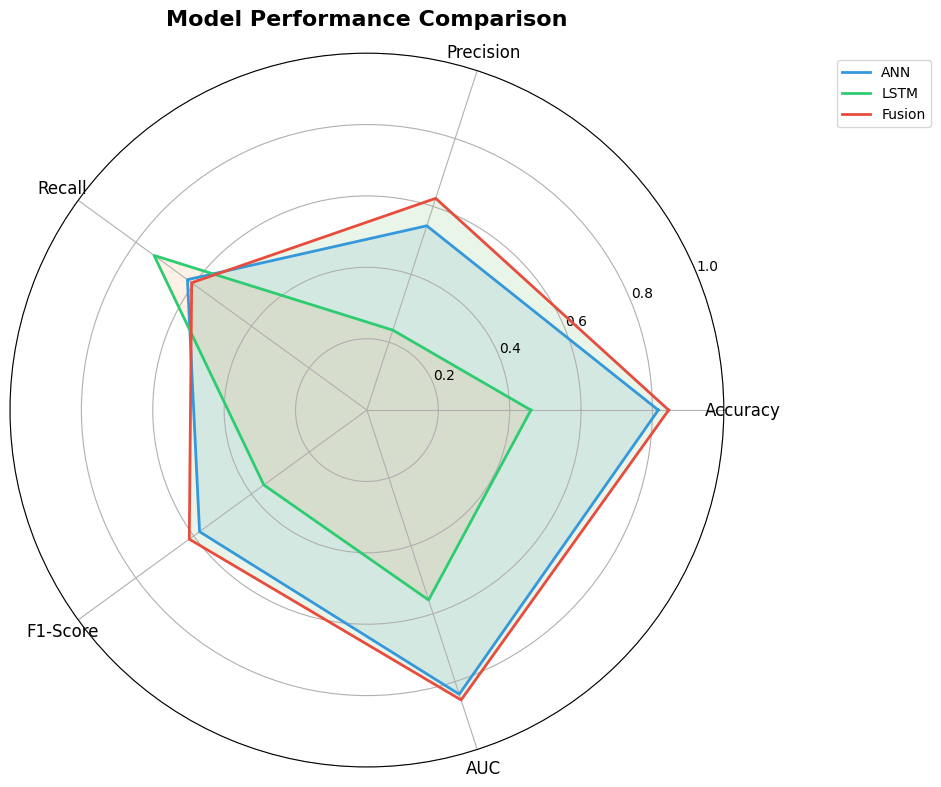

In [10]:
# CELL 10: Create Summary Visualization
print("\n" + "=" * 60)
print("CREATING SUMMARY VISUALIZATION")
print("=" * 60)

# Radar chart for comprehensive comparison
from math import pi

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')

# Number of variables
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
N = len(categories)

# Create angles for each category
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Plot each model
for i, (name, metrics) in enumerate(results.items()):
    values = [metrics[cat] for cat in categories]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=name, 
            color=['#3498db', '#2ecc71', '#e74c3c'][i])
    ax.fill(angles, values, alpha=0.1)

# Set category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)

# Set y-axis limits
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])

ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig('../models/radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# CELL 11: Save Comparison Results
print("\n" + "=" * 60)
print("SAVING COMPARISON RESULTS")
print("=" * 60)

# Save to CSV
results_df.to_csv('../models/model_comparison.csv')
print("✅ Comparison saved to ../models/model_comparison.csv")

# Create summary text file
with open('../models/comparison_summary.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("MODEL COMPARISON SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    
    for name, metrics in results.items():
        f.write(f"{name} MODEL:\n")
        f.write("-" * 30 + "\n")
        for metric, value in metrics.items():
            f.write(f"  {metric}: {value:.4f}\n")
        f.write("\n")
    
    f.write("\nBEST MODELS BY METRIC:\n")
    f.write("-" * 30 + "\n")
    f.write(f"  Best Accuracy:  {best_accuracy}\n")
    f.write(f"  Best F1-Score:  {best_f1}\n")
    f.write(f"  Best AUC:       {best_auc}\n")

print("✅ Summary saved to ../models/comparison_summary.txt")


SAVING COMPARISON RESULTS
✅ Comparison saved to ../models/model_comparison.csv
✅ Summary saved to ../models/comparison_summary.txt
